# A/B-тестирование: планирование, анализ и подглядывание

Математика калькулятора и сверка формул с `statsmodels` / `scipy`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_effectsize,
    proportions_ztest,
)

from ab_core import (
    analyze_continuous,
    analyze_proportions,
    mde_from_sample_size,
    peeking_curve,
    sample_size_proportions,
    test_duration_days,
)

warnings.filterwarnings("ignore")

SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": MUTED,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "grid.color": "#e1e0d9",
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "figure.dpi": 120,
    "lines.linewidth": 2,
    "legend.frameon": False,
})


def fmt(x):
    return f"{x:,.0f}".replace(",", " ")

## 1. Размер выборки

$$
n = \frac{\left(z_{1-\alpha/2}\sqrt{2\bar{p}(1-\bar{p})}
+ z_{1-\beta}\sqrt{p_1(1-p_1)+p_2(1-p_2)}\right)^2}{(p_2-p_1)^2},
\qquad \bar p = \frac{p_1+p_2}{2}
$$

In [2]:
p_base, mde_rel = 0.05, 0.10
mde_abs = p_base * mde_rel

n = sample_size_proportions(p_base, mde_abs, alpha=0.05, power=0.80)
days = test_duration_days(n, daily_users=5000)

print(f"{p_base:.1%} → {p_base + mde_abs:.1%}")
print(f"На группу: {fmt(n)}, всего: {fmt(2 * n)}, дней при 5000/день: {days:.1f}")

5.0% → 5.5%
На группу: 31 234, всего: 62 468, дней при 5000/день: 12.5


Сверка со `statsmodels` (там другое приближение, через арксинус, поэтому совпадение до долей процента):

In [3]:
rows = []
for p, mde in [(0.02, 0.004), (0.05, 0.005), (0.10, 0.010), (0.20, 0.020), (0.35, 0.030)]:
    mine = sample_size_proportions(p, mde)
    ref = NormalIndPower().solve_power(proportion_effectsize(p + mde, p), alpha=0.05, power=0.80)
    rows.append({
        "База": f"{p:.0%}",
        "MDE, п.п.": f"{mde * 100:.1f}",
        "ab_core": fmt(mine),
        "statsmodels": fmt(ref),
        "Расхождение": f"{abs(mine - ref) / ref:.2%}",
    })
pd.DataFrame(rows)

,База,"MDE, п.п.",ab_core,statsmodels,Расхождение
0,2%,0.4,21 109,21 066,0.20%
1,5%,0.5,31 234,31 217,0.05%
2,10%,1.0,14 751,14 744,0.05%
3,20%,2.0,6 510,6 507,0.04%
4,35%,3.0,4 042,4 041,0.03%


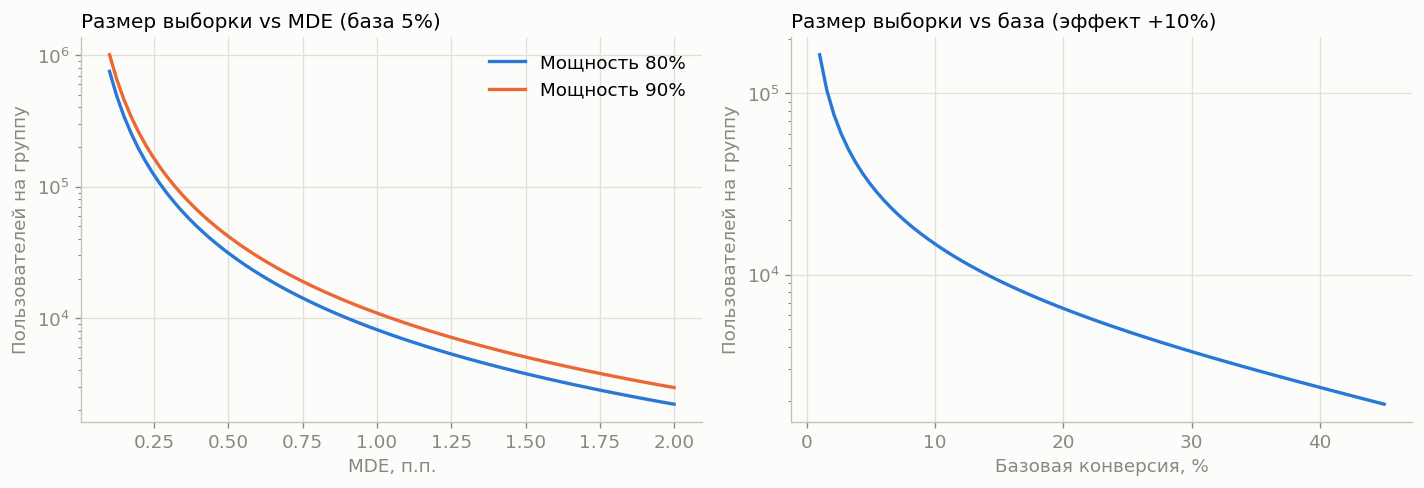

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

mde_grid = np.linspace(0.001, 0.02, 80)
for power, color in [(0.80, BLUE), (0.90, ORANGE)]:
    ax1.plot(mde_grid * 100, [sample_size_proportions(0.05, m, 0.05, power) for m in mde_grid],
             color=color, label=f"Мощность {power:.0%}")
ax1.set(yscale="log", xlabel="MDE, п.п.", ylabel="Пользователей на группу",
        title="Размер выборки vs MDE (база 5%)")
ax1.legend()

bases = np.linspace(0.01, 0.45, 80)
ax2.plot(bases * 100, [sample_size_proportions(b, b * 0.10) for b in bases], color=BLUE)
ax2.set(yscale="log", xlabel="Базовая конверсия, %", ylabel="Пользователей на группу",
        title="Размер выборки vs база (эффект +10%)")

plt.tight_layout()
plt.show()

In [5]:
pd.DataFrame([
    {
        "На группу": fmt(n_avail),
        "MDE, п.п.": f"{mde_from_sample_size(0.05, n_avail) * 100:.3f}",
        "MDE отн.": f"{mde_from_sample_size(0.05, n_avail) / 0.05:.1%}",
    }
    for n_avail in [1_000, 5_000, 20_000, 100_000, 500_000]
])

,На группу,"MDE, п.п.",MDE отн.
0,1 000,3.098,62.0%
1,5 000,1.293,25.9%
2,20 000,0.628,12.6%
3,100 000,0.277,5.5%
4,500 000,0.123,2.5%


## 2. Анализ результата

$$
z = \frac{\hat p_B - \hat p_A}{\sqrt{\hat p(1-\hat p)\left(\frac{1}{n_A}+\frac{1}{n_B}\right)}},
\qquad \hat p = \frac{x_A + x_B}{n_A + n_B}
$$

Статистика — на объединённой дисперсии, доверительный интервал — на раздельной.

In [6]:
res = analyze_proportions(n_a=10_000, conv_a=500, n_b=10_000, conv_b=560)

print(f"A: {res.p_a:.3%}   B: {res.p_b:.3%}")
print(f"Эффект: {res.diff_abs * 100:+.3f} п.п. ({res.lift_rel:+.2%})")
print(f"z = {res.z_stat:+.4f}, p-value = {res.p_value:.4f}")
print(f"95% ДИ: [{res.diff_ci[0] * 100:+.3f}; {res.diff_ci[1] * 100:+.3f}] п.п., "
      f"[{res.lift_ci[0]:+.2%}; {res.lift_ci[1]:+.2%}] отн.")
print(f"MDE при такой выборке: {res.mde_achievable * 100:.3f} п.п.")

A: 5.000%   B: 5.600%
Эффект: +0.600 п.п. (+12.00%)
z = +1.8938, p-value = 0.0583
95% ДИ: [-0.021; +1.221] п.п., [-0.40%; +25.95%] отн.
MDE при такой выборке: 0.899 п.п.


In [7]:
z_ref, p_ref = proportions_ztest([560, 500], [10_000, 10_000])
ci_ref = confint_proportions_2indep(560, 10_000, 500, 10_000, method="wald")

pd.DataFrame({
    "ab_core": [res.z_stat, res.p_value, *res.diff_ci],
    "statsmodels": [z_ref, p_ref, *ci_ref],
}, index=["z", "p-value", "ДИ нижн.", "ДИ верхн."]).round(6)

,ab_core,statsmodels
z,1.893753,1.893753
p-value,0.058258,0.058258
ДИ нижн.,-0.000209,-0.000209
ДИ верхн.,0.012209,0.012209


### Распределение p-value при H₀ и H₁

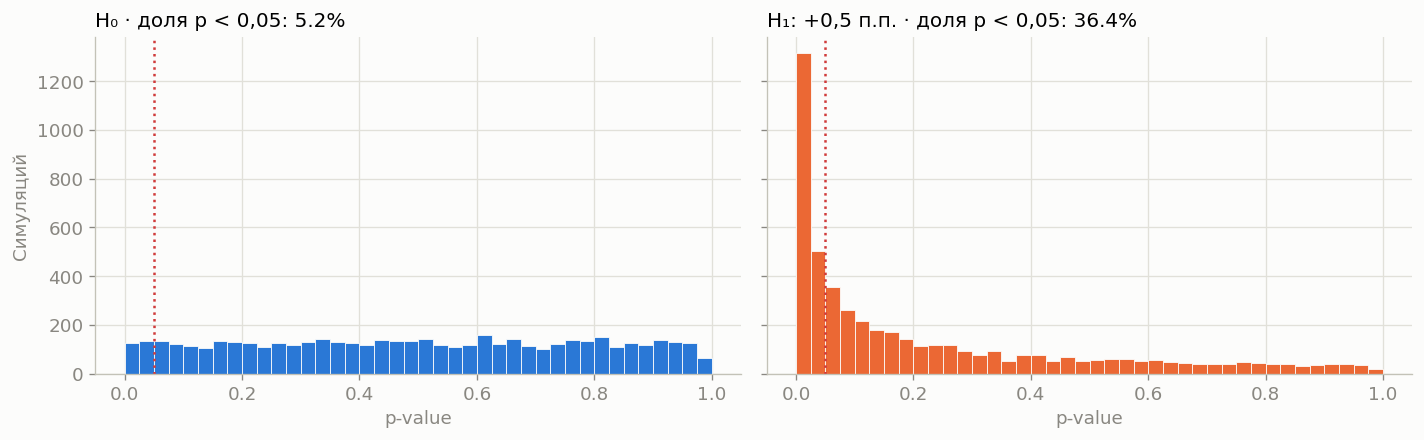

In [8]:
def simulate_pvalues(p_a, p_b, n, n_sims=5000, seed=0):
    rng = np.random.default_rng(seed)
    x_a, x_b = rng.binomial(n, p_a, n_sims), rng.binomial(n, p_b, n_sims)
    pool = (x_a + x_b) / (2 * n)
    se = np.sqrt(np.clip(pool * (1 - pool) * 2 / n, 1e-12, None))
    return 2 * stats.norm.sf(np.abs((x_b - x_a) / n / se))


p_h0 = simulate_pvalues(0.05, 0.05, 10_000, seed=1)
p_h1 = simulate_pvalues(0.05, 0.055, 10_000, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, data, color, title in [(axes[0], p_h0, BLUE, "H₀"), (axes[1], p_h1, ORANGE, "H₁: +0,5 п.п.")]:
    ax.hist(data, bins=40, range=(0, 1), color=color, edgecolor=SURFACE, linewidth=0.5)
    ax.axvline(0.05, color=RED, linestyle=":", linewidth=1.5)
    ax.set(xlabel="p-value", title=f"{title} · доля p < 0,05: {(data < 0.05).mean():.1%}")
axes[0].set_ylabel("Симуляций")
plt.tight_layout()
plt.show()

## 3. Подглядывание

A/A-тест: эффекта нет, любое «значимо» — ложное.

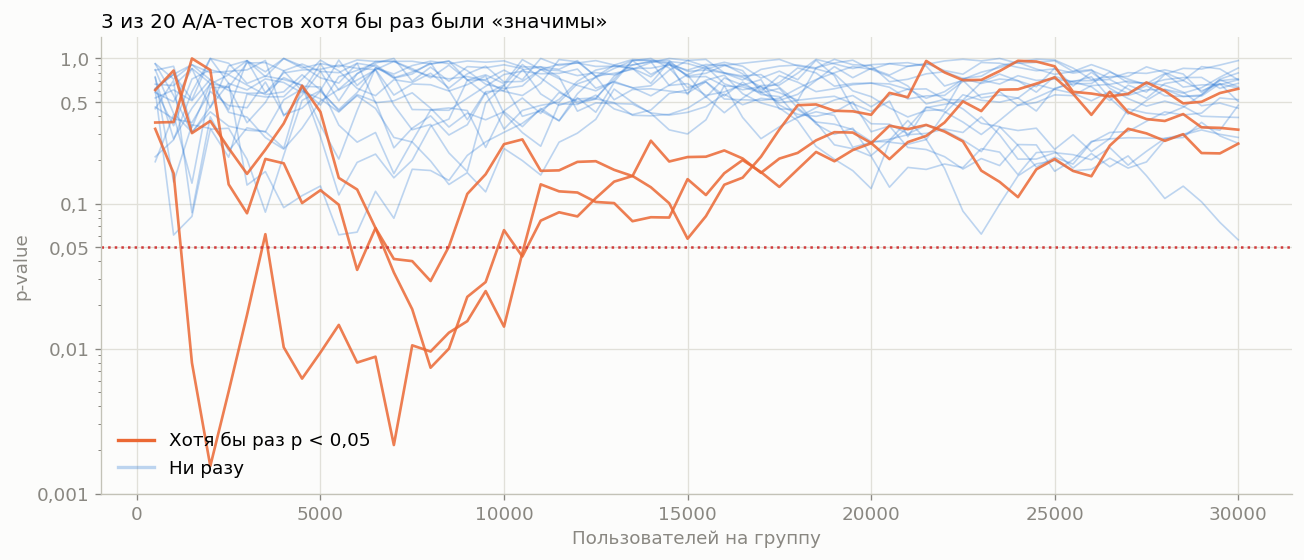

In [9]:
def pvalue_paths(n_total, n_paths, p=0.10, n_points=60, seed=0):
    rng = np.random.default_rng(seed)
    checkpoints = np.linspace(n_total / n_points, n_total, n_points).round().astype(int)
    inc = np.diff(np.concatenate([[0], checkpoints]))
    cum_a = np.cumsum(rng.binomial(inc, p, size=(n_paths, n_points)), axis=1)
    cum_b = np.cumsum(rng.binomial(inc, p, size=(n_paths, n_points)), axis=1)
    n_at = checkpoints[None, :]
    pool = (cum_a + cum_b) / (2 * n_at)
    se = np.sqrt(np.clip(pool * (1 - pool) * 2 / n_at, 1e-12, None))
    return checkpoints, 2 * stats.norm.sf(np.abs((cum_b - cum_a) / n_at / se))


N_PATHS = 20
checkpoints, paths = pvalue_paths(30_000, N_PATHS, seed=11)
crossed = (paths < 0.05).any(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.8))
for path in paths[~crossed]:
    ax.plot(checkpoints, path, color=BLUE, alpha=0.3, linewidth=1)
for path in paths[crossed]:
    ax.plot(checkpoints, path, color=ORANGE, alpha=0.85, linewidth=1.6)
ax.axhline(0.05, color=RED, linestyle=":", linewidth=1.5)
ax.set_yscale("log")
ax.set_ylim(1e-3, 1.4)
ax.set_yticks([0.001, 0.01, 0.05, 0.1, 0.5, 1.0], ["0,001", "0,01", "0,05", "0,1", "0,5", "1,0"])
ax.set(xlabel="Пользователей на группу", ylabel="p-value",
       title=f"{crossed.sum()} из {N_PATHS} A/A-тестов хотя бы раз были «значимы»")
ax.legend(handles=[
    Line2D([], [], color=ORANGE, label="Хотя бы раз p < 0,05"),
    Line2D([], [], color=BLUE, alpha=0.3, label="Ни разу"),
], loc="lower left")
plt.tight_layout()
plt.show()

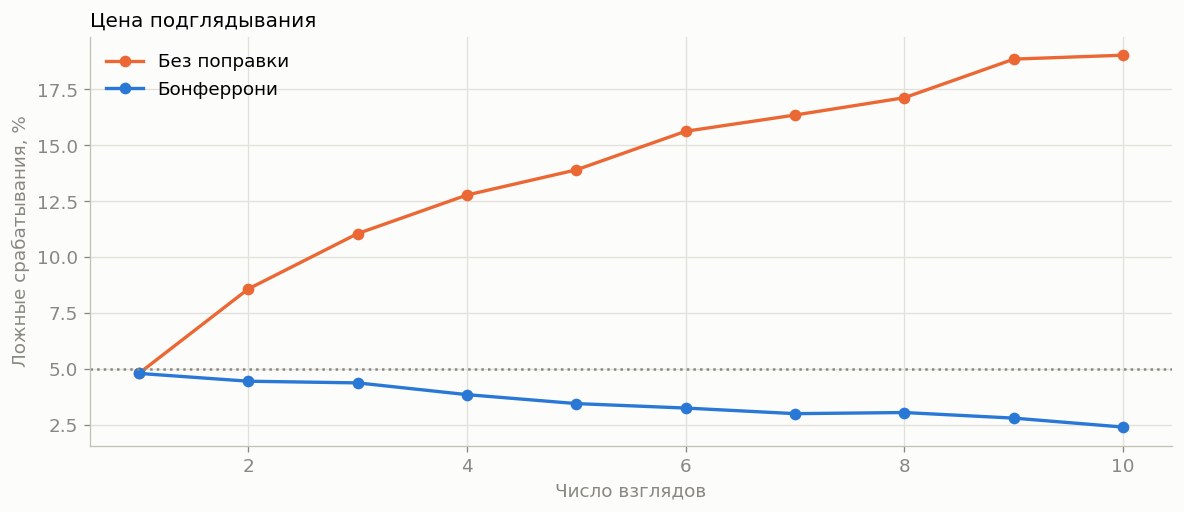

,Взглядов,Без поправки,Бонферрони,Только финал
0,1,4.80%,4.80%,4.80%
1,2,8.58%,4.45%,5.10%
2,3,11.05%,4.38%,5.25%
3,4,12.78%,3.85%,6.15%
4,5,13.90%,3.45%,4.83%
5,6,15.62%,3.25%,5.17%
6,7,16.35%,3.00%,4.98%
7,8,17.12%,3.05%,5.12%
8,9,18.85%,2.80%,4.60%
9,10,19.02%,2.40%,4.80%


In [10]:
curve = peeking_curve(n_per_group=20_000, max_looks=10, p_base=0.10, n_sims=4000)
looks = [c["n_looks"] for c in curve]
naive = [c["naive"] * 100 for c in curve]
bonf = [c["bonferroni"] * 100 for c in curve]

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(looks, naive, color=ORANGE, marker="o", label="Без поправки")
ax.plot(looks, bonf, color=BLUE, marker="o", label="Бонферрони")
ax.axhline(5, color=MUTED, linestyle=":", linewidth=1.5)
ax.set(xlabel="Число взглядов", ylabel="Ложные срабатывания, %", title="Цена подглядывания")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "Взглядов": looks,
    "Без поправки": [f"{v:.2f}%" for v in naive],
    "Бонферрони": [f"{v:.2f}%" for v in bonf],
    "Только финал": [f"{c['final_only']:.2%}" for c in curve],
})

## 4. Непрерывные метрики (тест Уэлча)

In [11]:
rng = np.random.default_rng(5)
rev_a = rng.lognormal(mean=6.0, sigma=1.1, size=4_000)
rev_b = rng.lognormal(mean=6.05, sigma=1.1, size=4_000)

res_c = analyze_continuous(rev_a, rev_b)
t_ref, p_ref = stats.ttest_ind(rev_b, rev_a, equal_var=False)

print(f"A: {res_c.mean_a:,.1f} ₽   B: {res_c.mean_b:,.1f} ₽")
print(f"Разница: {res_c.diff:+,.1f} ₽ ({res_c.lift_rel:+.2%})")
print(f"95% ДИ: [{res_c.diff_ci[0]:+,.1f}; {res_c.diff_ci[1]:+,.1f}] ₽")
print(f"ab_core: t = {res_c.t_stat:+.6f}, p = {res_c.p_value:.6f}")
print(f"scipy:   t = {t_ref:+.6f}, p = {p_ref:.6f}")

A: 756.8 ₽   B: 801.3 ₽
Разница: +44.5 ₽ (+5.87%)
95% ДИ: [-7.0; +96.0] ₽
ab_core: t = +1.692272, p = 0.090634
scipy:   t = +1.692272, p = 0.090634


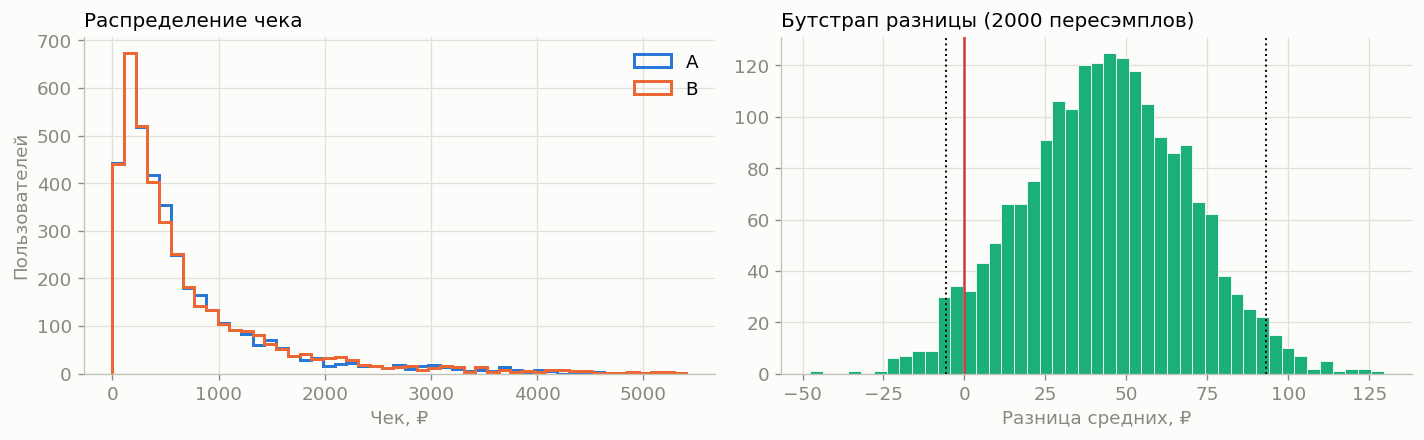

ДИ Уэлч:     [-7.0; +96.0] ₽
ДИ бутстрап: [-5.7; +93.2] ₽


In [12]:
boot = np.array([
    rng.choice(rev_b, len(rev_b)).mean() - rng.choice(rev_a, len(rev_a)).mean()
    for _ in range(2_000)
])
lo, hi = np.percentile(boot, [2.5, 97.5])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
bins = np.linspace(0, np.percentile(np.r_[rev_a, rev_b], 99), 50)
ax1.hist(rev_a, bins=bins, histtype="step", color=BLUE, linewidth=1.8, label="A")
ax1.hist(rev_b, bins=bins, histtype="step", color=ORANGE, linewidth=1.8, label="B")
ax1.set(xlabel="Чек, ₽", ylabel="Пользователей", title="Распределение чека")
ax1.legend()

ax2.hist(boot, bins=45, color=AQUA, edgecolor=SURFACE, linewidth=0.5)
for q in (lo, hi):
    ax2.axvline(q, color=INK, linestyle=":", linewidth=1.2)
ax2.axvline(0, color=RED, linewidth=1.5)
ax2.set(xlabel="Разница средних, ₽", title="Бутстрап разницы (2000 пересэмплов)")
plt.tight_layout()
plt.show()

print(f"ДИ Уэлч:     [{res_c.diff_ci[0]:+,.1f}; {res_c.diff_ci[1]:+,.1f}] ₽")
print(f"ДИ бутстрап: [{lo:+,.1f}; {hi:+,.1f}] ₽")

## Итоги

* Размер выборки сходится со `statsmodels` с точностью до 0,2%.
* z-тест и ДИ совпадают со `statsmodels`, тест Уэлча — со `scipy`, его ДИ — с бутстрапом.
* При H₀ p-value равномерно, доля ложных срабатываний ≈ α.
* 10 взглядов вместо одного поднимают долю ложных срабатываний с 5% до ~19%.